In [ ]:
!pip -q install lightning torchmetrics scipy scikit-learn networkx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 56.0 MB/s eta 0:00:00


In [ ]:
import os
import random
import numpy as np
import scipy.linalg
import scipy.sparse.csgraph as csgraph
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import lightning.pytorch as L
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
from torchmetrics.classification import MulticlassAccuracy, MulticlassF1Score

import matplotlib.pyplot as plt
import seaborn as sns


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

CONFIG = {
    "fs": 128,
    "n_channels": 16,
    "var_order": 5,
    "batch_size": 16,
    "lr": 1e-4,
    "weight_decay": 1e-6,
    "max_epochs": 100,
    "num_workers": 2,
    "n_splits": 5,
    "num_classes": 2,
    "device": "cuda" if torch.cuda.is_available() else "cpu"
}

print(CONFIG)

{'fs': 128, 'n_channels': 16, 'var_order': 5, 'batch_size': 16, 'lr': 0.0001, 'weight_decay': 1e-06, 'max_epochs': 100, 'num_workers': 2, 'n_splits': 5, 'num_classes': 2, 'device': 'cuda'}


In [ ]:
X_old = np.load("/content/X_raw.npy").astype(np.float32)

X_corrected = []

for subject in X_old:
    flat_original = subject.T.reshape(-1)

    eeg_correct = flat_original.reshape(16, 7680)

    X_corrected.append(eeg_correct)

X_raw = np.stack(X_corrected).astype(np.float32)

print("Corrected shape:", X_raw.shape)

np.save("/content/X_raw_corrected.npy", X_raw)

Corrected shape: (84, 16, 7680)


In [ ]:
X_raw = np.load("/content/X_raw_corrected.npy")
y = np.load("/content/y.npy")

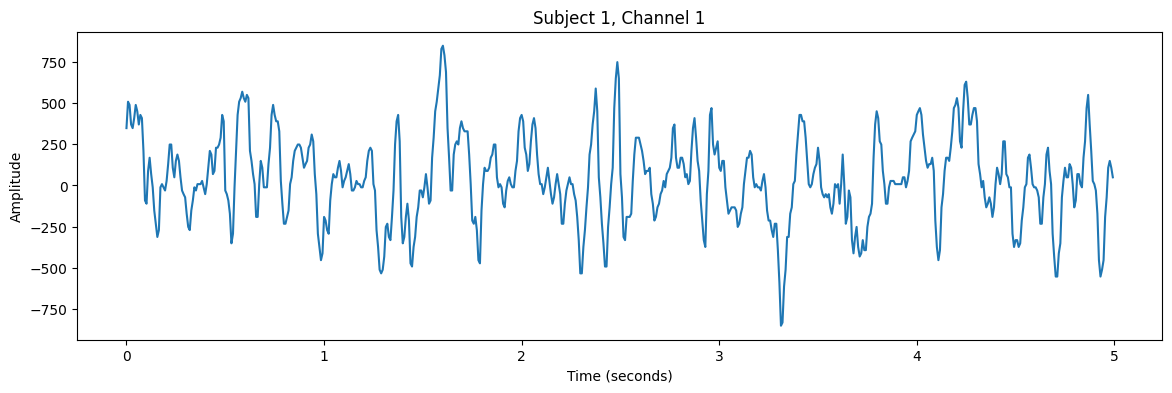

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fs = 128
subject_idx = 0
channel_idx = 0
seconds = 5

n = fs * seconds
time = np.arange(n) / fs

plt.figure(figsize=(14, 4))
plt.plot(time, X_raw[subject_idx, channel_idx, :n])
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Subject 1, Channel 1")
plt.show()

In [ ]:
print(X_raw.min())
print(X_raw.max())
print(X_raw.mean())
print(X_raw.std())

-4570.0
4227.16
4.4800634
410.85114


In [ ]:
print(X_raw.shape)

(84, 16, 7680)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from scipy import signal
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler


FS = 128
N_CHANNELS = 16
EXPECTED_SAMPLES = 7680

LOW_CUT = 1.0
HIGH_CUT = 45.0
NOTCH_FREQ = 50.0

# Artifact settings
WINDOW_SECONDS = 1.0
ROBUST_Z_THRESHOLD = 8.0
MAX_ARTIFACT_FRACTION = 0.20

CHANNEL_NAMES = [
    "F7", "F3", "F4", "F8",
    "T3", "C3", "Cz", "C4",
    "T4", "T5", "P3", "Pz",
    "P4", "T6", "O1", "O2"
]



X_raw = np.load("/content/X_raw.npy").astype(np.float64)
y = np.load("/content/y.npy").astype(np.int64)

print("Raw EEG shape:", X_raw.shape)
print("Labels shape:", y.shape)
print("Class counts:", np.bincount(y))

assert X_raw.ndim == 3
assert X_raw.shape[1] == N_CHANNELS
assert X_raw.shape[2] == EXPECTED_SAMPLES
assert len(X_raw) == len(y)

# X_raw: (84, 16, 7680)
# y:     (84,)

Raw EEG shape: (84, 16, 7680)
Labels shape: (84,)
Class counts: [39 45]


In [ ]:
def remove_dc_offset(eeg):

    return eeg - np.mean(eeg, axis=1, keepdims=True)


def apply_notch_filter(eeg, fs=128, notch_freq=50.0, quality_factor=30.0):

    b, a = signal.iirnotch(
        w0=notch_freq,
        Q=quality_factor,
        fs=fs
    )

    return signal.filtfilt(
        b,
        a,
        eeg,
        axis=1
    )


def apply_bandpass_filter(
    eeg,
    fs=128,
    low_cut=1.0,
    high_cut=45.0,
    order=4
):

    sos = signal.butter(
        N=order,
        Wn=[low_cut, high_cut],
        btype="bandpass",
        fs=fs,
        output="sos"
    )

    return signal.sosfiltfilt(
        sos,
        eeg,
        axis=1
    )

In [ ]:
def robust_zscore(x, axis=-1, eps=1e-8):

    median = np.median(x, axis=axis, keepdims=True)
    mad = np.median(np.abs(x - median), axis=axis, keepdims=True)

    robust_std = 1.4826 * mad + eps
    return (x - median) / robust_std


def expand_mask(mask, samples_to_expand):
    if samples_to_expand <= 0:
        return mask

    kernel = np.ones(2 * samples_to_expand + 1, dtype=int)

    expanded = np.zeros_like(mask, dtype=bool)

    for ch in range(mask.shape[0]):
        expanded[ch] = (
            np.convolve(mask[ch].astype(int), kernel, mode="same") > 0
        )

    return expanded


def interpolate_bad_samples(channel, bad_mask):
    channel = channel.copy()

    good_idx = np.where(~bad_mask)[0]
    bad_idx = np.where(bad_mask)[0]

    if len(bad_idx) == 0:
        return channel

    if len(good_idx) < 2:
        raise ValueError("Too few clean samples for interpolation.")

    channel[bad_idx] = np.interp(
        bad_idx,
        good_idx,
        channel[good_idx]
    )

    return channel


def remove_artifacts(
    eeg,
    fs=128,
    robust_z_threshold=12.0,
    expansion_ms=25
):
    z = robust_zscore(eeg, axis=1)

    bad_mask = np.abs(z) > robust_z_threshold

    expansion_samples = int(expansion_ms / 1000 * fs)
    bad_mask = expand_mask(bad_mask, expansion_samples)

    cleaned = eeg.copy()

    for ch in range(eeg.shape[0]):
        bad_fraction = bad_mask[ch].mean()

        if bad_fraction > 0.10:
            print(
                f"Warning: channel {ch} has "
                f"{bad_fraction:.1%} flagged; leaving it unchanged."
            )
            continue

        cleaned[ch] = interpolate_bad_samples(
            cleaned[ch],
            bad_mask[ch]
        )

    return cleaned, float(bad_mask.mean()), bad_mask

In [ ]:
def common_average_reference(eeg):
    average_reference = np.mean(eeg, axis=0, keepdims=True)
    return eeg - average_reference


def zscore_channels(eeg, eps=1e-8):
    mean = np.mean(eeg, axis=1, keepdims=True)
    std = np.std(eeg, axis=1, keepdims=True)

    return (eeg - mean) / (std + eps)


def quality_check(eeg, artifact_fraction):

    report = {
        "has_nan": bool(np.isnan(eeg).any()),
        "has_inf": bool(np.isinf(eeg).any()),
        "artifact_fraction": float(artifact_fraction)
    }

    channel_std = np.std(eeg, axis=1)

    report["channel_std"] = channel_std
    report["flat_channels"] = np.where(channel_std < 1e-6)[0].tolist()
    report["extreme_channels"] = np.where(channel_std > 10.0)[0].tolist()

    report["passes_quality_check"] = (
        not report["has_nan"]
        and not report["has_inf"]
        and len(report["flat_channels"]) == 0
        and artifact_fraction <= MAX_ARTIFACT_FRACTION
    )

    return report

In [ ]:
import numpy as np
from scipy import signal


def preprocess_subject(eeg, fs=FS):
    eeg = np.asarray(eeg, dtype=np.float64)
    eeg_processed = signal.detrend(eeg, axis=1, type="linear")
    eeg_processed = remove_dc_offset(eeg_processed)

    eeg_processed = apply_notch_filter(eeg_processed, fs=fs, notch_freq=NOTCH_FREQ)
    eeg_processed = apply_bandpass_filter(eeg_processed, fs=fs, low_cut=LOW_CUT, high_cut=HIGH_CUT)
    eeg_processed, artifact_fraction, bad_mask = remove_artifacts(
        eeg_processed,
        fs=fs,
        robust_z_threshold=ROBUST_Z_THRESHOLD
    )

    eeg_processed = common_average_reference(eeg_processed)
    eeg_processed = zscore_channels(eeg_processed)
    quality_report = quality_check(eeg_processed, artifact_fraction)

    if not quality_report["passes_quality_check"]:
        print(f"{artifact_fraction:.2f}")

    return eeg_processed.astype(np.float32)

In [ ]:
subject_1st = 0
eeg_single_subject = X_raw[subject_1st].copy()

print(f"Processing subject {subject_1st} with shape: {eeg_single_subject.shape}")

# Removing DC offset
eeg_cleaned = remove_dc_offset(eeg_single_subject)

# Notch Filter
eeg_cleaned = apply_notch_filter(eeg_cleaned, fs=FS, notch_freq=NOTCH_FREQ)

# Band-Pass Filter
eeg_cleaned = apply_bandpass_filter(eeg_cleaned, fs=FS, low_cut=LOW_CUT, high_cut=HIGH_CUT)

# Artifact Handling
eeg_cleaned_artifacts, artifact_fraction_demo, bad_mask_demo = remove_artifacts(
    eeg_cleaned,
    fs=FS,
    robust_z_threshold=ROBUST_Z_THRESHOLD
)

print(f"Artifact fraction for subject {subject_1st}: {artifact_fraction_demo:.4f}")

# Common-Average Reference
eeg_cleaned_artifacts = common_average_reference(eeg_cleaned_artifacts)

# Per-Channel Standardization
eeg_cleaned_artifacts = zscore_channels(eeg_cleaned_artifacts)

quality_report = quality_check(eeg_cleaned_artifacts, artifact_fraction_demo)

print(f"\nQuality Check Report for subject {subject_1st}:")
for key, value in quality_report.items():
    print(f"  {key}: {value}")

if quality_report["passes_quality_check"]:
    print(f"Subject {subject_1st} PASSED quality check.")
else:
    print(f"Subject {subject_1st} FAILED quality check. Review report for details.")

Processing subject 0 with shape: (16, 7680)
Artifact fraction for subject 0: 0.0000

Quality Check Report for subject 0:
  has_nan: False
  has_inf: False
  artifact_fraction: 0.0
  channel_std: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  flat_channels: []
  extreme_channels: []
  passes_quality_check: True
Subject 0 PASSED quality check.


In [ ]:
X_preprocessed = np.stack(
    [preprocess_subject(subject, fs=FS) for subject in X_raw],
    axis=0
)

print(X_preprocessed.shape)
print(X_preprocessed.min())
print(X_preprocessed.max())
print(X_preprocessed.mean())
print(X_preprocessed.std())

(84, 16, 7680)
-9.304944
9.440608
-7.206663e-12
1.0000004


In [ ]:
np.save(
    "/content/X_processed.npy",
    X_raw
)

np.save(
    "/content/y_processed.npy",
    y
)

print("Saved:")
print("/content/X_processed.npy")
print("/content/y_processed.npy")

Saved:
/content/X_processed.npy
/content/y_processed.npy


# **Main Model**

In [ ]:
from sklearn.metrics import f1_score

def compute_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    # Sensitivity (recall for class 1 - schizophrenia)
    sensitivity = recall_score(y_true, y_pred, pos_label=1)
    # Specificity (recall for class 0 - healthy control)
    specificity = recall_score(y_true, y_pred, pos_label=0)
    # F1 Score
    f1 = f1_score(y_true, y_pred, average='macro')
    return {
        "accuracy": accuracy,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "f1_score": f1
    }

def print_metrics(name, metrics):
    print(f"\n{name}:")
    print(f"  Accuracy: {metrics['accuracy']:.4f}")
    print(f"  Sensitivity: {metrics['sensitivity']:.4f}")
    print(f"  Specificity: {metrics['specificity']:.4f}")
    print(f"  Modified Accuracy: {(metrics['sensitivity'] + metrics['specificity']) / 2:.4f}")
    print(f"  F1 Score: {metrics['f1_score']:.4f}")

In [ ]:
# Data loading

def load_dataset(x_path="/content/X_processed.npy", y_path="/content/y_processed.npy"):
    X_raw = np.load(x_path)
    y = np.load(y_path)

    assert X_raw.ndim == 3, "X_raw must be shape (subjects, channels, time)"
    assert X_raw.shape[1] == CONFIG["n_channels"], "Expected 16 EEG channels"
    assert y.ndim == 1, "y must be shape (subjects,)"

    print("X_raw:", X_raw.shape)
    print("y:", y.shape)
    print("Class counts:", np.bincount(y.astype(int)))

    return X_raw.astype(np.float32), y.astype(np.int64)


In [ ]:
# VAR Feature Extraction

def fit_var_coefficients(eeg, order=5):

    N, T = eeg.shape
    L = order


    Y = eeg[:, L:].T
    X_list = []
    for lag in range(1, L + 1):
        X_list.append(eeg[:, L - lag:T - lag].T)

    X = np.concatenate(X_list, axis=1)

    beta = np.linalg.pinv(X) @ Y

    phi = []
    for lag_idx in range(L):
        block = beta[lag_idx * N:(lag_idx + 1) * N, :]
        phi_lag = block.T
        np.fill_diagonal(phi_lag, 0.0)
        phi.append(phi_lag)

    phi = np.stack(phi, axis=0)
    return phi.astype(np.float32)


def extract_var_features_all(X_raw, order=5):
    features = []
    for i in range(len(X_raw)):
        phi = fit_var_coefficients(X_raw[i], order=order)
        features.append(phi)
    return np.stack(features, axis=0)  # (subjects, 5, 16, 16)

In [ ]:
# PDC Feature Extraction

BANDS = {
    "delta": (1, 4),
    "theta": (4, 7),
    "alpha": (8, 13),
    "beta": (14, 30),
    "gamma": (30, 64)
}

def compute_pdc_from_var(phi, fs=128, freqs=None):

    L, N, _ = phi.shape

    if freqs is None:
        freqs = np.linspace(1, fs / 2, 64)

    pdc_all = []

    I = np.eye(N, dtype=np.complex64)

    for f in freqs:
        A_f = I.copy()

        for lag in range(1, L + 1):
            A_f -= phi[lag - 1] * np.exp(-1j * 2 * np.pi * lag * f / fs)

        denom = np.sqrt(np.sum(np.abs(A_f) ** 2, axis=0, keepdims=True)) + 1e-8
        pdc = np.abs(A_f) / denom

        np.fill_diagonal(pdc, 0.0)
        pdc_all.append(pdc.real.astype(np.float32))

    return np.stack(pdc_all, axis=0)


def band_average_pdc(phi, fs=128):

    band_features = []

    for band_name, (low, high) in BANDS.items():
        freqs = np.linspace(low, high, 16)
        pdc_freq = compute_pdc_from_var(phi, fs=fs, freqs=freqs)
        pdc_band = pdc_freq.mean(axis=0)
        np.fill_diagonal(pdc_band, 0.0)
        band_features.append(pdc_band)

    return np.stack(band_features, axis=0).astype(np.float32)


def extract_pdc_features_all(var_features, fs=128):

    features = []
    for i in range(len(var_features)):
        pdc = band_average_pdc(var_features[i], fs=fs)
        features.append(pdc)
    return np.stack(features, axis=0)

In [ ]:
# Complex Network features
# 16 degree values, 1 global efficiency, 16 clustering coefficient values, 1 transitivity

def weighted_degree(W):
    return np.sum(W, axis=1)


def global_efficiency(W):

    W = W.copy()
    np.fill_diagonal(W, 0.0)

    distance = np.where(W > 0, 1.0 / (W + 1e-8), np.inf)
    np.fill_diagonal(distance, 0.0)

    shortest = csgraph.shortest_path(distance, directed=False, unweighted=False)
    inv_shortest = np.where(shortest > 0, 1.0 / (shortest + 1e-8), 0.0)

    N = W.shape[0]
    return np.sum(inv_shortest) / (N * (N - 1))


def weighted_clustering_coefficients(W):

    W = W.copy()
    np.fill_diagonal(W, 0.0)

    W = (W + W.T) / 2.0
    max_w = W.max() + 1e-8
    Wn = W / max_w

    N = W.shape[0]
    C = np.zeros(N, dtype=np.float32)

    for i in range(N):
        neighbors = np.where(Wn[i] > 0)[0]
        k = len(neighbors)

        if k < 2:
            C[i] = 0.0
            continue

        triangle_sum = 0.0
        for a in range(k):
            for b in range(a + 1, k):
                j = neighbors[a]
                h = neighbors[b]
                triangle_sum += (Wn[i, j] * Wn[i, h] * Wn[j, h]) ** (1.0 / 3.0)

        C[i] = (2.0 * triangle_sum) / (k * (k - 1))

    return C


def transitivity(W):

    C = weighted_clustering_coefficients(W)
    return float(np.mean(C))


def compute_cn_for_pdc_subject(pdc_subject):

    band_cn = []

    for b in range(pdc_subject.shape[0]):
        W = pdc_subject[b]

        W = (W + W.T) / 2.0
        np.fill_diagonal(W, 0.0)

        deg = weighted_degree(W)
        ge = np.array([global_efficiency(W)])
        cc = weighted_clustering_coefficients(W)
        tr = np.array([transitivity(W)])

        feat = np.concatenate([deg, ge, cc, tr], axis=0)
        band_cn.append(feat)

    return np.stack(band_cn, axis=0).astype(np.float32)


def extract_cn_features_all(pdc_features):

    features = []
    for i in range(len(pdc_features)):
        cn = compute_cn_for_pdc_subject(pdc_features[i])
        features.append(cn)
    return np.stack(features, axis=0)

In [ ]:
# Feature Extraction for each 3 paths

def extract_all_features(X_raw):
    print("Extracting VAR features...")
    X_var = extract_var_features_all(X_raw, order=CONFIG["var_order"])
    print("VAR:", X_var.shape)

    print("Extracting PDC features...")
    X_pdc = extract_pdc_features_all(X_var, fs=CONFIG["fs"])
    print("PDC:", X_pdc.shape)

    print("Extracting CN features...")
    X_cn = extract_cn_features_all(X_pdc)
    print("CN:", X_cn.shape)

    return X_var, X_pdc, X_cn


In [ ]:
class ConnectivityDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def standardize_train_test(X_train, X_test):

    original_shape = X_train.shape[1:]

    scaler = StandardScaler()

    X_train_flat = X_train.reshape(X_train.shape[0], -1)
    X_test_flat = X_test.reshape(X_test.shape[0], -1)

    X_train_scaled = scaler.fit_transform(X_train_flat)
    X_test_scaled = scaler.transform(X_test_flat)

    X_train_scaled = X_train_scaled.reshape(-1, *original_shape)
    X_test_scaled = X_test_scaled.reshape(-1, *original_shape)

    return X_train_scaled.astype(np.float32), X_test_scaled.astype(np.float32)


def make_loaders(X_train, y_train, X_val, y_val):
    train_ds = ConnectivityDataset(X_train, y_train)
    val_ds = ConnectivityDataset(X_val, y_val)

    train_loader = DataLoader(
        train_ds,
        batch_size=CONFIG["batch_size"],
        shuffle=True,
        num_workers=CONFIG["num_workers"]
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=CONFIG["batch_size"],
        shuffle=False,
        num_workers=CONFIG["num_workers"]
    )

    return train_loader, val_loader

In [ ]:
# 2D-CNN FOR VAR/PDC

class Connectome2DCNN(nn.Module):
    def __init__(self, in_channels=5, num_classes=2):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, 128, kernel_size=3, stride=1, padding=1)
        self.dropout = nn.Dropout(0.2)
        self.conv2 = nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1)
        self.pool = nn.AdaptiveAvgPool2d(8)
        self.flatten = nn.Flatten()

        # 64 feature maps x 16 x 16 = 16384
        self.fc1 = nn.Linear(64 * 8 * 8, 64)

        self.out = nn.Linear(64, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.dropout(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)

        x = self.flatten(x)
        x = F.relu(self.fc1(x))

        logits = self.out(x)
        return logits

In [ ]:
# 1D-CNN FOR CN FEATURES
# channels = 5 frequency bands

class CN1DCNN(nn.Module):
    def __init__(self, in_channels=5, num_classes=2):
        super().__init__()

        self.conv1 = nn.Conv1d(in_channels, 8, kernel_size=3, stride=1, padding=1)
        self.dropout = nn.Dropout(0.2)
        self.pool = nn.AvgPool1d(kernel_size=2, stride=2)

        # input length 34 -> pool -> 17
        self.fc1 = nn.Linear(8 * 17, 32)
        self.out = nn.Linear(32, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.dropout(x)
        x = self.pool(x)

        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.fc1(x))

        logits = self.out(x)
        return logits

In [ ]:
import lightning.pytorch as L
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
from torchmetrics.classification import MulticlassAccuracy, MulticlassF1Score

class LitClassifier(L.LightningModule):
    def __init__(self, model, lr=1e-4, weight_decay=1e-6):
        super().__init__()
        self.model = model
        self.lr = lr
        self.weight_decay = weight_decay

        self.train_acc = MulticlassAccuracy(num_classes=2)
        self.val_acc = MulticlassAccuracy(num_classes=2)
        self.train_f1 = MulticlassF1Score(num_classes=2)
        self.val_f1 = MulticlassF1Score(num_classes=2)

        self.train_loss_hist = []
        self.val_loss_hist = []
        self.train_f1_hist = []
        self.val_f1_hist = []
        self.train_acc_hist = []
        self.val_acc_hist = []

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)

        loss = F.cross_entropy(logits, y)
        preds = torch.argmax(logits, dim=1)

        acc = self.train_acc(preds, y)
        f1 = self.train_f1(preds, y)

        self.log("train_loss", loss, prog_bar=True)
        self.log("train_acc", acc, prog_bar=True)
        self.log("train_f1", f1, prog_bar=True)

        return loss

    def on_train_epoch_end(self):
        # Store aggregated epoch-end metrics
        self.train_loss_hist.append(self.trainer.callback_metrics["train_loss"].item())
        self.train_f1_hist.append(self.train_f1.compute().item())
        self.train_acc_hist.append(self.train_acc.compute().item())
        self.train_acc.reset()
        self.train_f1.reset()

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)

        loss = F.cross_entropy(logits, y)
        preds = torch.argmax(logits, dim=1)

        acc = self.val_acc(preds, y)
        f1 = self.val_f1(preds, y)

        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", acc, prog_bar=True)
        self.log("val_f1", f1, prog_bar=True)

        return loss

    def on_validation_epoch_end(self):

        self.val_loss_hist.append(self.trainer.callback_metrics["val_loss"].item())
        self.val_f1_hist.append(self.val_f1.compute().item())
        self.val_acc_hist.append(self.val_acc.compute().item())
        self.val_acc.reset()
        self.val_f1.reset()

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(
            self.parameters(),
            lr=self.lr,
            weight_decay=self.weight_decay
        )
        return optimizer

# Not in usage currently

    # def configure_optimizers(self):
    #     optimizer = torch.optim.Adam(
    #         self.parameters(),
    #         lr=self.lr,
    #         weight_decay=self.weight_decay
    #     )

    #     scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    #         optimizer,
    #         mode='min',       # Reduce when monitored metric stops decreasing
    #         factor=0.1,       # New LR = old LR * 0.1
    #         patience=10,      # Wait 10 epochs before reducing
    #         min_lr=1e-7,
    #     )

    #     return {
    #         "optimizer": optimizer,
    #         "lr_scheduler": {
    #             "scheduler": scheduler,
    #             "monitor": "val_loss",   # Must match the logged validation loss name
    #             "interval": "epoch",
    #             "frequency": 1,
    #         },
    #     }

In [ ]:
# Training 1 branch

def train_one_branch(X, y, train_idx, val_idx, branch_type="var", fold=0):

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    X_train, X_val = standardize_train_test(X_train, X_val)

    train_loader, val_loader = make_loaders(X_train, y_train, X_val, y_val)

    if branch_type in ["var", "pdc"]:
        model = Connectome2DCNN(in_channels=5, num_classes=2)
    elif branch_type == "cn":
        model = CN1DCNN(in_channels=5, num_classes=2)
    else:
        raise ValueError("Unknown branch type")

    lit_model = LitClassifier(
        model,
        lr=CONFIG["lr"],
        weight_decay=CONFIG["weight_decay"]
    )

    checkpoint = ModelCheckpoint(
        monitor="val_loss",
        mode="min",
        save_top_k=1,
        filename=f"{branch_type}_fold{fold}" + "_{epoch:02d}_{val_loss:.4f}"
    )

    trainer = L.Trainer(
        max_epochs=CONFIG["max_epochs"],
        accelerator="auto",
        devices=1,
        callbacks=[checkpoint],
        log_every_n_steps=10,
        enable_progress_bar=True
    )

    trainer.fit(lit_model, train_loader, val_loader)

    best_model_for_prediction = LitClassifier.load_from_checkpoint(
        checkpoint.best_model_path,
        model=model,
        lr=CONFIG["lr"],
        weight_decay=CONFIG["weight_decay"]
    )

    best_model_for_prediction.eval()
    best_model_for_prediction.to(CONFIG["device"])

    return best_model_for_prediction, X_val, y_val, lit_model

In [ ]:
# Prediction Function

@torch.no_grad()
def predict_model(model, X):
    model.eval()
    model.to(CONFIG["device"])

    ds = ConnectivityDataset(X, np.zeros(len(X), dtype=np.int64))
    loader = DataLoader(ds, batch_size=CONFIG["batch_size"], shuffle=False)

    all_probs = []
    all_preds = []

    for xb, _ in loader:
        xb = xb.to(CONFIG["device"])
        logits = model(xb)
        probs = F.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    all_probs = np.concatenate(all_probs, axis=0)
    all_preds = np.concatenate(all_preds, axis=0)

    return all_preds, all_probs

In [ ]:
# 5-FOLD DECISION-LEVEL FUSION
# Decision-level fusion:
# VAR-CNN predicts class
# PDC-CNN predicts class
# CN-CNN predicts class
# Final class = majority vote

In [ ]:
# Majority Vote technique
def majority_vote(pred_var, pred_pdc, pred_cn):
    stacked = np.stack([pred_var, pred_pdc, pred_cn], axis=1)
    final = []

    for row in stacked:
        counts = np.bincount(row, minlength=2)
        final.append(np.argmax(counts))

    return np.array(final)

In [ ]:
def run_5fold_decision_fusion(X_var, X_pdc, X_cn, y):
    skf = StratifiedKFold(
        n_splits=CONFIG["n_splits"],
        shuffle=True,
        random_state=SEED
    )

    all_y_true = []

    all_pred_var = []
    all_pred_pdc = []
    all_pred_cn = []
    all_pred_fusion = []

    fold_metrics = []

    all_var_train_loss_hist = []
    all_var_val_loss_hist = []
    all_var_train_f1_hist = []
    all_var_val_f1_hist = []
    all_var_train_acc_hist = []
    all_var_val_acc_hist = []

    all_pdc_train_loss_hist = []
    all_pdc_val_loss_hist = []
    all_pdc_train_f1_hist = []
    all_pdc_val_f1_hist = []
    all_pdc_train_acc_hist = []
    all_pdc_val_acc_hist = []

    all_cn_train_loss_hist = []
    all_cn_val_loss_hist = []
    all_cn_train_f1_hist = []
    all_cn_val_f1_hist = []
    all_cn_train_acc_hist = []
    all_cn_val_acc_hist = []


    for fold, (train_idx, val_idx) in enumerate(skf.split(X_var, y)):
        print("\n" + "=" * 60)
        print(f"FOLD {fold + 1}/{CONFIG['n_splits']}")
        print("=" * 60)


        # Train VAR branch
        print("\nTraining VAR branch...")
        var_model_for_pred, X_var_val_scaled, y_val, var_model_with_history = train_one_branch(
            X_var, y, train_idx, val_idx, branch_type="var", fold=fold
        )

        pred_var, prob_var = predict_model(var_model_for_pred, X_var_val_scaled)

        all_var_train_loss_hist.append(var_model_with_history.train_loss_hist)
        all_var_val_loss_hist.append(var_model_with_history.val_loss_hist)
        all_var_train_f1_hist.append(var_model_with_history.train_f1_hist)
        all_var_val_f1_hist.append(var_model_with_history.val_f1_hist)
        all_var_train_acc_hist.append(var_model_with_history.train_acc_hist)
        all_var_val_acc_hist.append(var_model_with_history.val_acc_hist)


        # Train PDC branch
        print("\nTraining PDC branch...")
        pdc_model_for_pred, X_pdc_val_scaled, _, pdc_model_with_history = train_one_branch(
            X_pdc, y, train_idx, val_idx, branch_type="pdc", fold=fold
        )
        pred_pdc, prob_pdc = predict_model(pdc_model_for_pred, X_pdc_val_scaled)

        all_pdc_train_loss_hist.append(pdc_model_with_history.train_loss_hist)
        all_pdc_val_loss_hist.append(pdc_model_with_history.val_loss_hist)
        all_pdc_train_f1_hist.append(pdc_model_with_history.train_f1_hist)
        all_pdc_val_f1_hist.append(pdc_model_with_history.val_f1_hist)
        all_pdc_train_acc_hist.append(pdc_model_with_history.train_acc_hist)
        all_pdc_val_acc_hist.append(pdc_model_with_history.val_acc_hist)

        # Train CN branch
        print("\nTraining CN branch...")
        cn_model_for_pred, X_cn_val_scaled, _, cn_model_with_history = train_one_branch(
            X_cn, y, train_idx, val_idx, branch_type="cn", fold=fold
        )
        pred_cn, prob_cn = predict_model(cn_model_for_pred, X_cn_val_scaled)

        all_cn_train_loss_hist.append(cn_model_with_history.train_loss_hist)
        all_cn_val_loss_hist.append(cn_model_with_history.val_loss_hist)
        all_cn_train_f1_hist.append(cn_model_with_history.train_f1_hist)
        all_cn_val_f1_hist.append(cn_model_with_history.val_f1_hist)
        all_cn_train_acc_hist.append(cn_model_with_history.train_acc_hist)
        all_cn_val_acc_hist.append(cn_model_with_history.val_acc_hist)


        # Majority Voting
        pred_fusion = majority_vote(pred_var, pred_pdc, pred_cn)

        all_y_true.append(y_val)

        all_pred_var.append(pred_var)
        all_pred_pdc.append(pred_pdc)
        all_pred_cn.append(pred_cn)
        all_pred_fusion.append(pred_fusion)

        metrics_fusion = compute_metrics(y_val, pred_fusion)
        fold_metrics.append(metrics_fusion)

        print_metrics(f"Fold {fold + 1} Fusion Metrics", metrics_fusion)

    # combine all folds
    y_true_all = np.concatenate(all_y_true)
    pred_var_all = np.concatenate(all_pred_var)
    pred_pdc_all = np.concatenate(all_pred_pdc)
    pred_cn_all = np.concatenate(all_pred_cn)
    pred_fusion_all = np.concatenate(all_pred_fusion)

    print("\n" + "=" * 60)
    print("FINAL 5-FOLD RESULTS")
    print("=" * 60)

    print_metrics("VAR branch", compute_metrics(y_true_all, pred_var_all))
    print_metrics("PDC branch", compute_metrics(y_true_all, pred_pdc_all))
    print_metrics("CN branch", compute_metrics(y_true_all, pred_cn_all))
    print_metrics("Decision-level Fusion", compute_metrics(y_true_all, pred_fusion_all))

    return {
        "y_true": y_true_all,
        "pred_var": pred_var_all,
        "pred_pdc": pred_pdc_all,
        "pred_cn": pred_cn_all,
        "pred_fusion": pred_fusion_all,
        "var_train_loss_hist": all_var_train_loss_hist,
        "var_val_loss_hist": all_var_val_loss_hist,
        "var_train_f1_hist": all_var_train_f1_hist,
        "var_val_f1_hist": all_var_val_f1_hist,
        "var_train_acc_hist": all_var_train_acc_hist,
        "var_val_acc_hist": all_var_val_acc_hist,

        "pdc_train_loss_hist": all_pdc_train_loss_hist,
        "pdc_val_loss_hist": all_pdc_val_loss_hist,
        "pdc_train_f1_hist": all_pdc_train_f1_hist,
        "pdc_val_f1_hist": all_pdc_val_f1_hist,
        "pdc_train_acc_hist": all_pdc_train_acc_hist,
        "pdc_val_acc_hist": all_pdc_val_acc_hist,

        "cn_train_loss_hist": all_cn_train_loss_hist,
        "cn_val_loss_hist": all_cn_val_loss_hist,
        "cn_train_f1_hist": all_cn_train_f1_hist,
        "cn_val_f1_hist": all_cn_val_f1_hist,
        "cn_train_acc_hist": all_cn_train_acc_hist,
        "cn_val_acc_hist": all_cn_val_acc_hist,
    }

In [ ]:
# ============================================================
# MODULE 15: RUN EVERYTHING
# ============================================================

# 1. Load raw EEG
X_processed, y_processed = load_dataset("/content/X_processed.npy", "/content/y_processed.npy")

# 2. Extract features
X_var, X_pdc, X_cn = extract_all_features(X_raw)

# 3. Or load precomputed features if already saved
# X_var = np.load("/content/X_var.npy")
# X_pdc = np.load("/content/X_pdc.npy")
# X_cn = np.load("/content/X_cn.npy")
# y = np.load("/content/y.npy")

# 4. Run 5-fold fusion
results = run_5fold_decision_fusion(X_var, X_pdc, X_cn, y)

X_raw: (84, 16, 7680)
y: (84,)
Class counts: [39 45]
Extracting VAR features...
VAR: (84, 5, 16, 16)
Extracting PDC features...
PDC: (84, 5, 16, 16)
Extracting CN features...


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


CN: (84, 5, 34)

FOLD 1/5

Training VAR branch...


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ Connectome2DCNN    │  342 K │ train │     0 │
│ 1 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 2 │ val_acc   │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ train_f1  │ MulticlassF1Score  │      0 │ train │     0 │
│ 4 │ val_f1    │ MulticlassF1Score  │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 342 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 342 K                                                                                                
Total estimated model params size (MB): 1.368                                                                      
Modules in train mode: 12                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/loops/fit_loop.py:321: The number of training batches (5)
is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you 
want to see logs for the training epoch.

INFO: `Trainer.fit` stopped: `max_epochs=100` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.



Fold 5 Fusion Metrics:
  Accuracy: 0.7500
  Sensitivity: 0.7778
  Specificity: 0.7143
  Modified Accuracy: 0.7460
  F1 Score: 0.7460

FINAL 5-FOLD RESULTS

VAR branch:
  Accuracy: 0.7738
  Sensitivity: 0.8222
  Specificity: 0.7179
  Modified Accuracy: 0.7701
  F1 Score: 0.7712

PDC branch:
  Accuracy: 0.7262
  Sensitivity: 0.7556
  Specificity: 0.6923
  Modified Accuracy: 0.7239
  F1 Score: 0.7243

CN branch:
  Accuracy: 0.6548
  Sensitivity: 0.8444
  Specificity: 0.4359
  Modified Accuracy: 0.6402
  F1 Score: 0.6317

Decision-level Fusion:
  Accuracy: 0.7619
  Sensitivity: 0.8667
  Specificity: 0.6410
  Modified Accuracy: 0.7538
  F1 Score: 0.7551


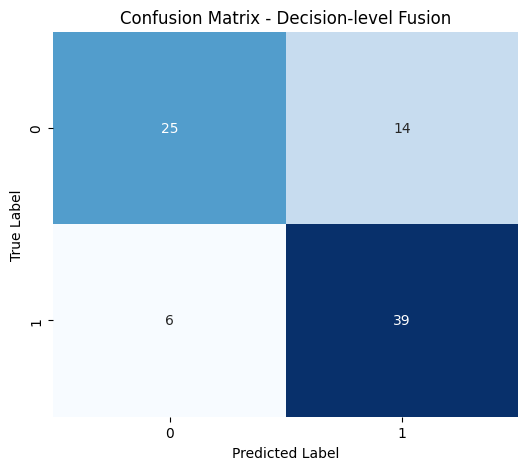

In [ ]:
cm = confusion_matrix(results['y_true'], results['pred_fusion'])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title('Confusion Matrix - Decision-level Fusion')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

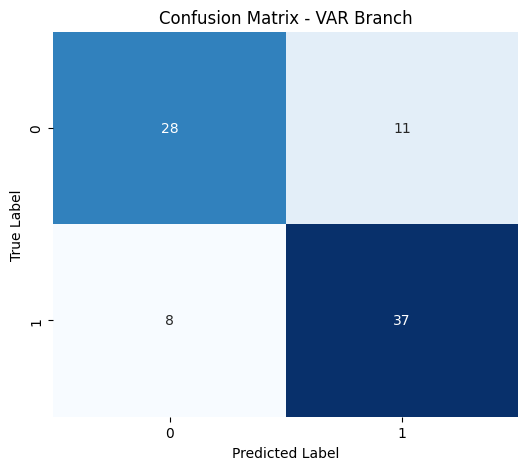

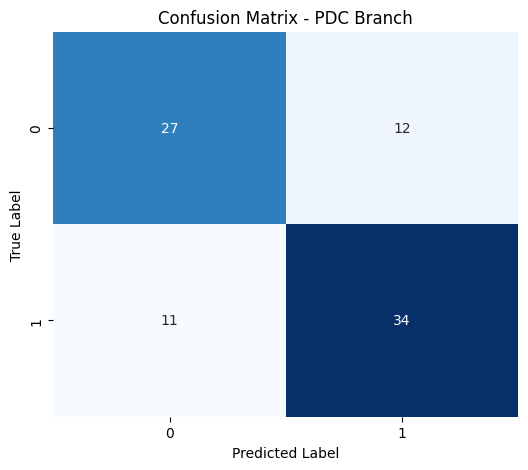

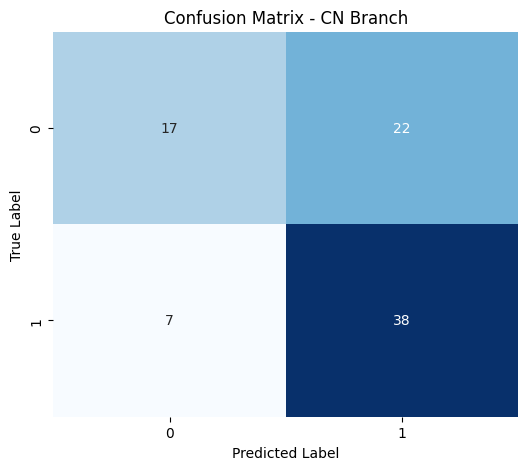

In [ ]:
branch_predictions = {
    'VAR Branch': results['pred_var'],
    'PDC Branch': results['pred_pdc'],
    'CN Branch': results['pred_cn']
}

for branch_name, predictions in branch_predictions.items():
    cm = confusion_matrix(results['y_true'], predictions)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f'Confusion Matrix - {branch_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

/tmp/ipykernel_5324/1145353256.py:17: RuntimeWarning: Mean of empty slice
  train_hist_mean = np.nanmean(padded_train_hist, axis=0)


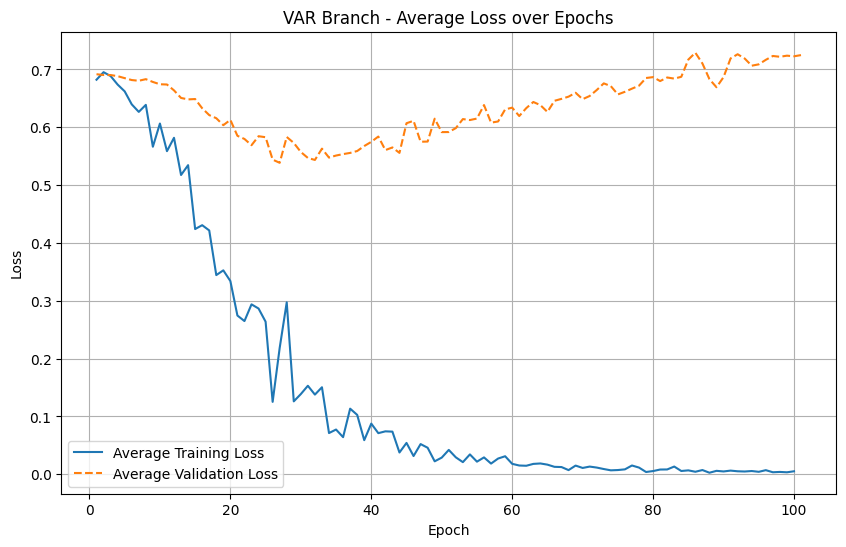

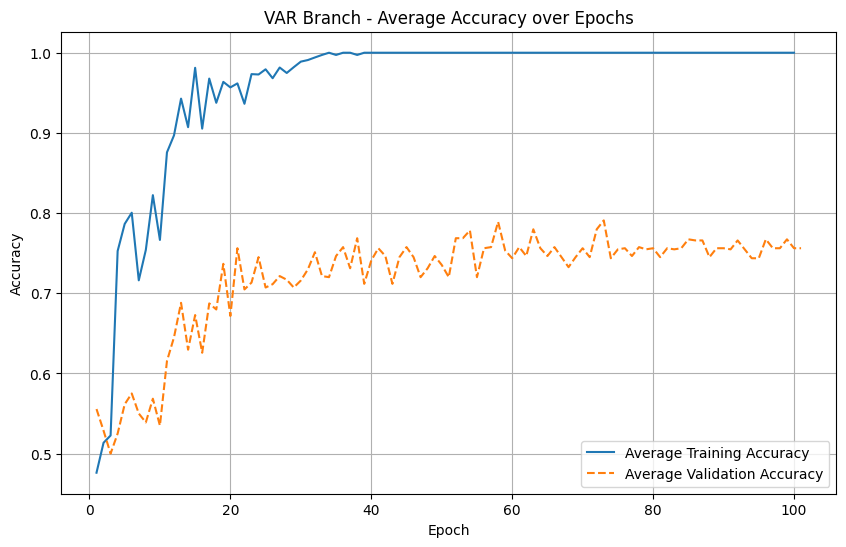

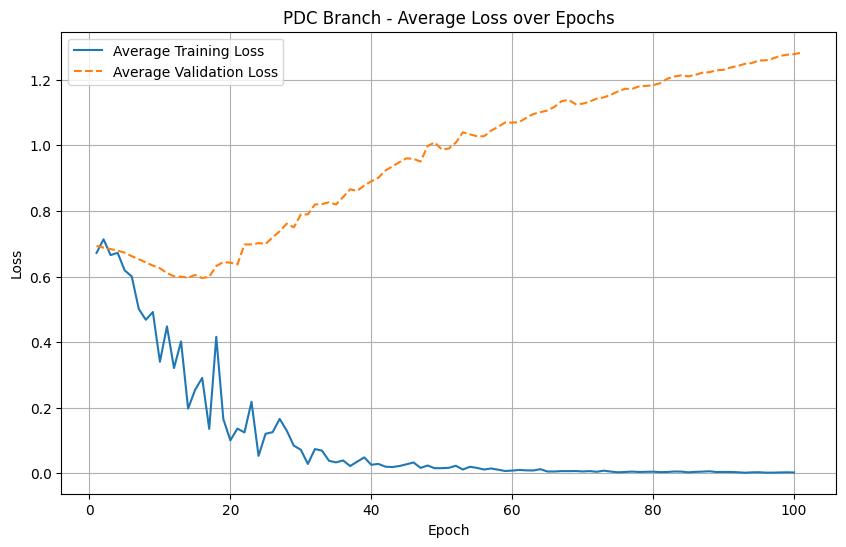

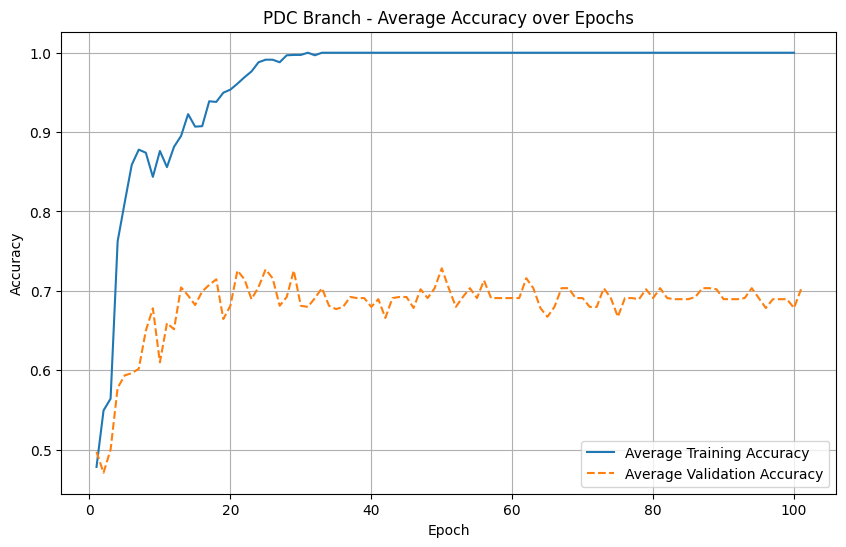

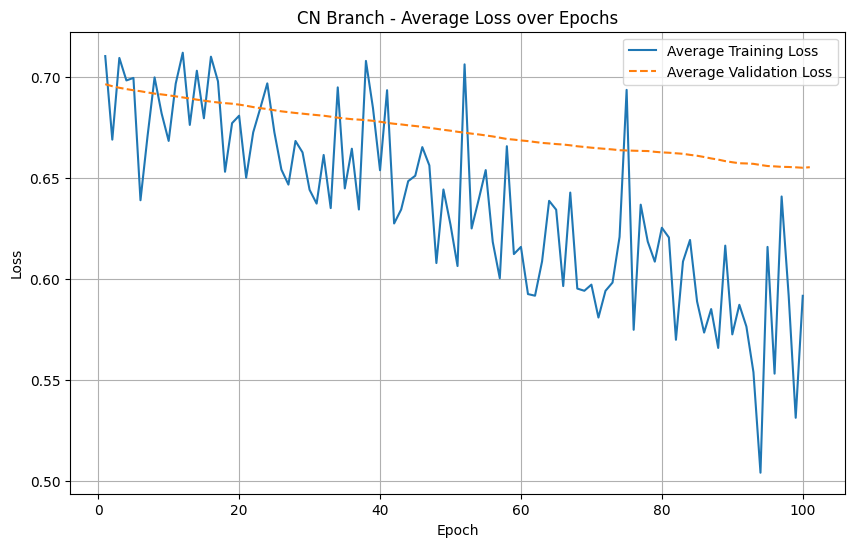

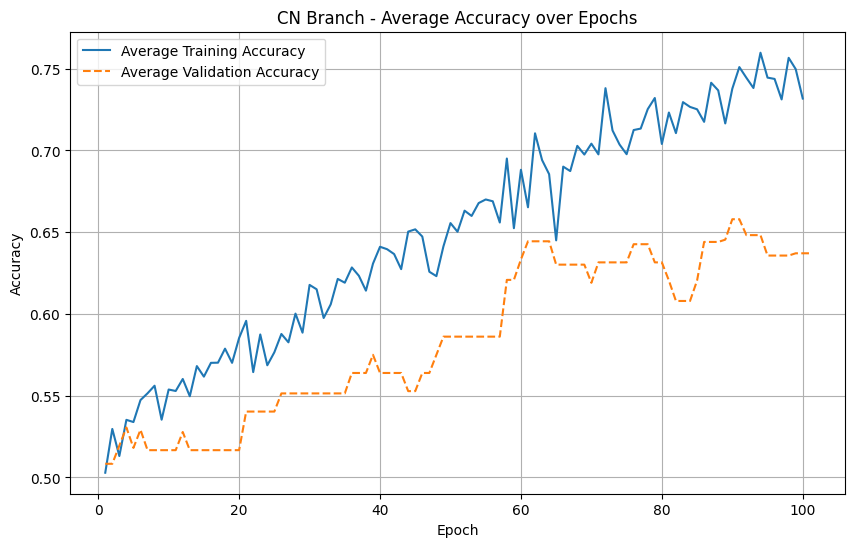

In [ ]:
# Plotting Loss & Accuracy Curves
def plot_history(train_history, val_history, metric_name, branch_type):
    max_epochs_train = max(len(h) for h in train_history) if train_history else 0
    max_epochs_val = max(len(h) for h in val_history) if val_history else 0
    max_epochs = max(max_epochs_train, max_epochs_val)

    if max_epochs == 0:
        print(f"No data available to plot {metric_name} for {branch_type} branch.")
        return

    padded_train_hist = [h + [np.nan] * (max_epochs - len(h)) for h in train_history]
    padded_val_hist = [h + [np.nan] * (max_epochs - len(h)) for h in val_history]

    train_hist_mean = np.nanmean(padded_train_hist, axis=0)
    val_hist_mean = np.nanmean(padded_val_hist, axis=0)

    epochs = range(1, len(train_hist_mean) + 1)

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_hist_mean, label=f'Average Training {metric_name}')
    plt.plot(epochs, val_hist_mean, label=f'Average Validation {metric_name}', linestyle='--')
    plt.title(f'{branch_type} Branch - Average {metric_name} over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel(metric_name)
    plt.legend()
    plt.grid(True)
    plt.show()

# VAR Branch Plots
plot_history(results['var_train_loss_hist'], results['var_val_loss_hist'], 'Loss', 'VAR')
plot_history(results['var_train_acc_hist'], results['var_val_acc_hist'], 'Accuracy', 'VAR')

# PDC Branch Plots
plot_history(results['pdc_train_loss_hist'], results['pdc_val_loss_hist'], 'Loss', 'PDC')
plot_history(results['pdc_train_acc_hist'], results['pdc_val_acc_hist'], 'Accuracy', 'PDC')

# CN Branch Plots
plot_history(results['cn_train_loss_hist'], results['cn_val_loss_hist'], 'Loss', 'CN')
plot_history(results['cn_train_acc_hist'], results['cn_val_acc_hist'], 'Accuracy', 'CN')

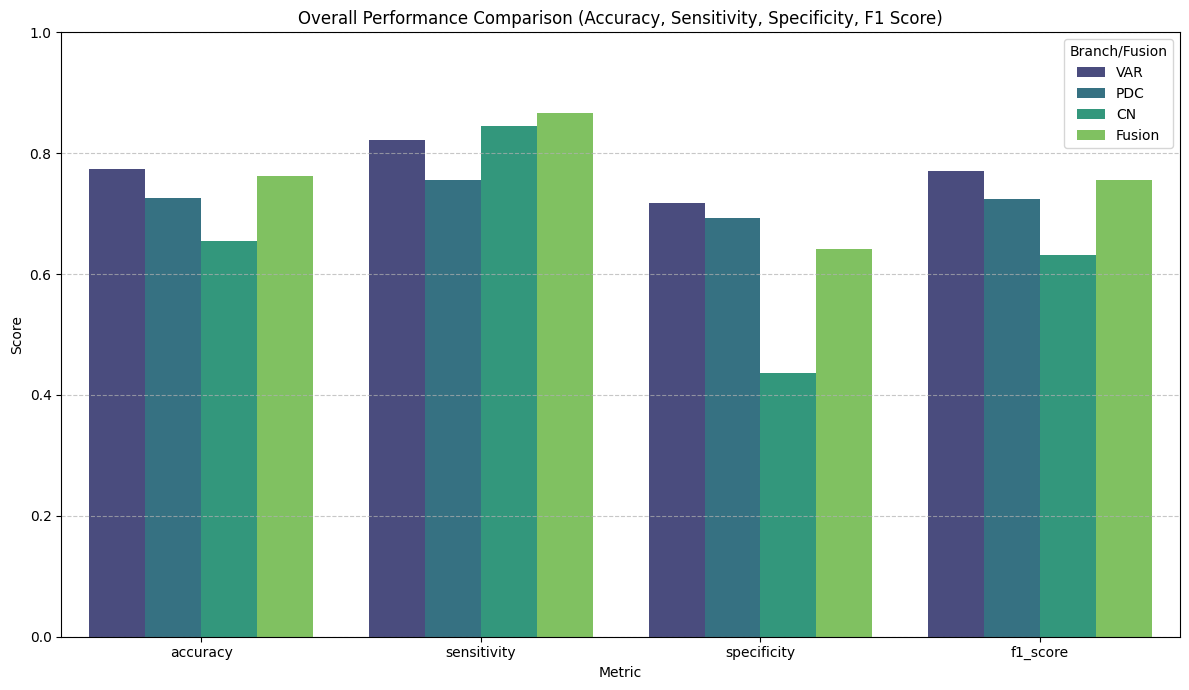


--- F1 Scores ---
VAR: 0.7712
PDC: 0.7243
CN: 0.6317
Fusion: 0.7551

--- Accuracy ---
VAR: 0.7738
PDC: 0.7262
CN: 0.6548
Fusion: 0.7619

--- Modified Accuracy ---
VAR: 0.7701
PDC: 0.7239
CN: 0.6402
Fusion: 0.7538


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

overall_metrics = {
    'VAR': compute_metrics(results['y_true'], results['pred_var']),
    'PDC': compute_metrics(results['y_true'], results['pred_pdc']),
    'CN': compute_metrics(results['y_true'], results['pred_cn']),
    'Fusion': compute_metrics(results['y_true'], results['pred_fusion'])
}

metrics_df = pd.DataFrame.from_dict(overall_metrics, orient='index')
metrics_df.index.name = 'Branch/Fusion'

metrics_df_melted = metrics_df.reset_index().melt(id_vars='Branch/Fusion', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 7))
sns.barplot(data=metrics_df_melted, x='Metric', y='Score', hue='Branch/Fusion', palette='viridis')
plt.title('Overall Performance Comparison (Accuracy, Sensitivity, Specificity, F1 Score)')
plt.ylabel('Score')
plt.xlabel('Metric')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title='Branch/Fusion'
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n--- F1 Scores ---")
for branch, metrics in overall_metrics.items():
    print(f"{branch}: {metrics['f1_score']:.4f}")

print("\n--- Accuracy ---")
for branch, metrics in overall_metrics.items():
    print(f"{branch}: {metrics['accuracy']:.4f}")

print("\n--- Modified Accuracy ---")
for branch, metrics in overall_metrics.items():
    modified_accuracy = (metrics['sensitivity'] + metrics['specificity']) / 2
    print(f"{branch}: {modified_accuracy:.4f}")